In [1]:
import os
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from PIL import Image
# from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# import tqdm
# import albumentations as A
# from albumentations.pytorch import ToTensorV2
# import segmentation_models_pytorch as smp

def visualize_sample(dataset, idx):
    image, mask,_,_ = dataset[idx]

    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).cpu().numpy()
    else:
        image = np.array(image)

    if isinstance(mask, torch.Tensor):
        mask = mask.squeeze().cpu().numpy()
    else:
        mask = np.squeeze(mask)

    fig, axes  = plt.subplots(1, 3, figsize = (15, 5))
    axes[0].imshow(image)
    axes[0].set_title('Image')
    axes[0].axis('off')

    axes[1].imshow(mask, cmap = 'gray')
    axes[1].set_title('Mask')
    axes[1].axis('off')

    axes[2].imshow(image)
    axes[2].imshow(mask, alpha = 0.5, cmap = 'jet')
    axes[2].set_title('Overlay')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

101


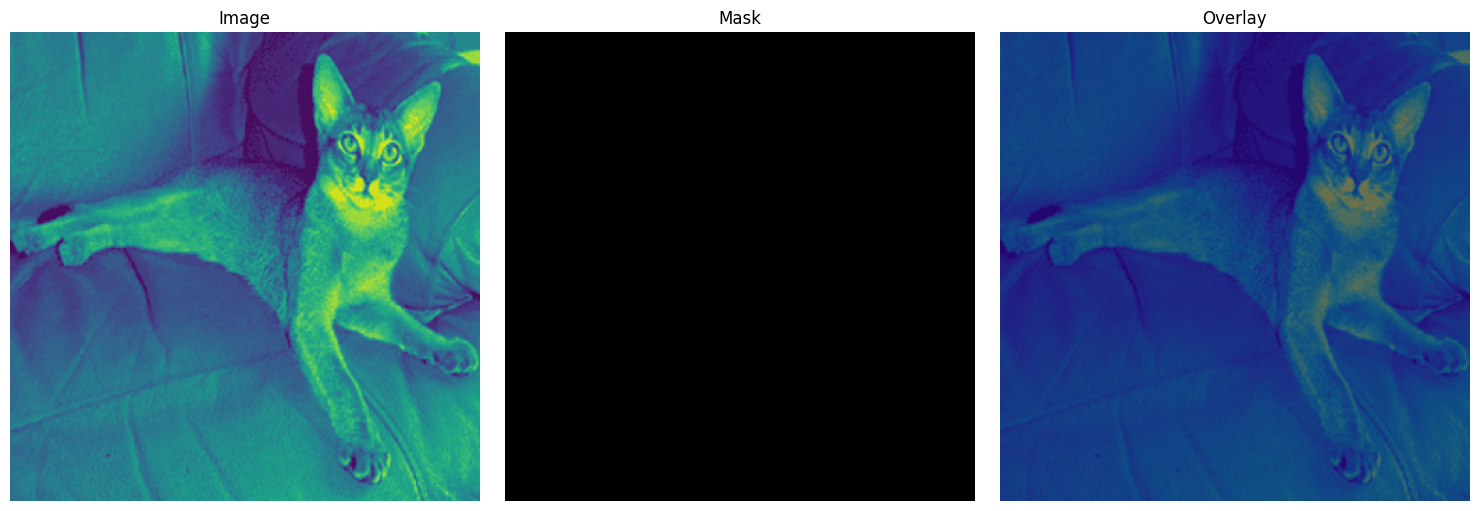

107


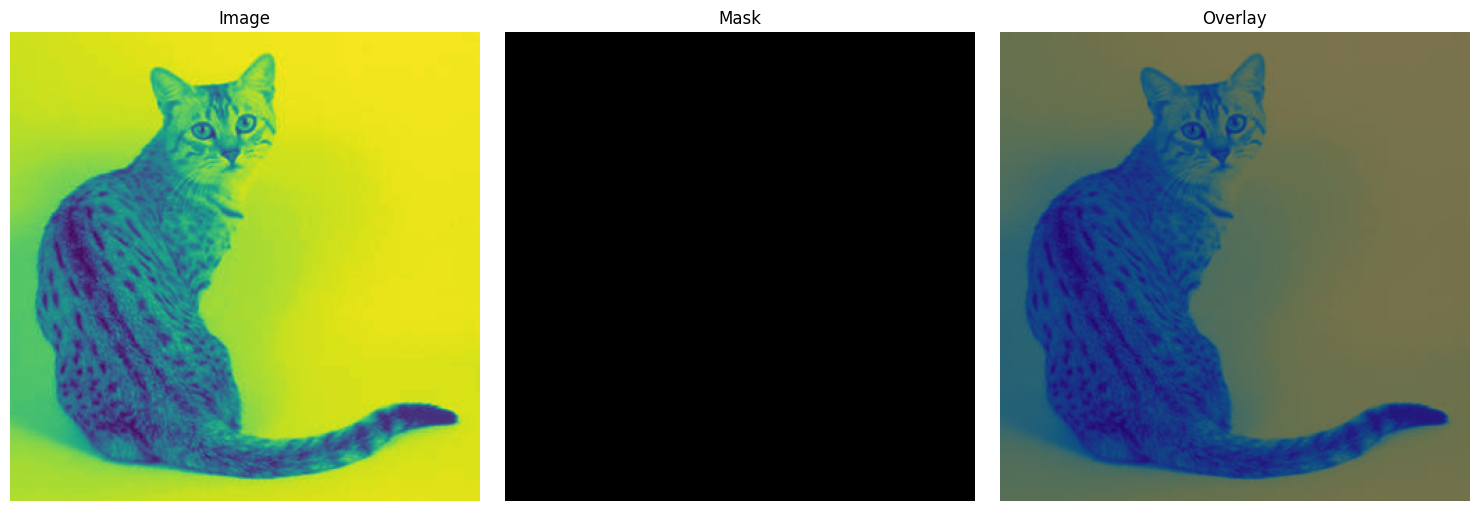

497


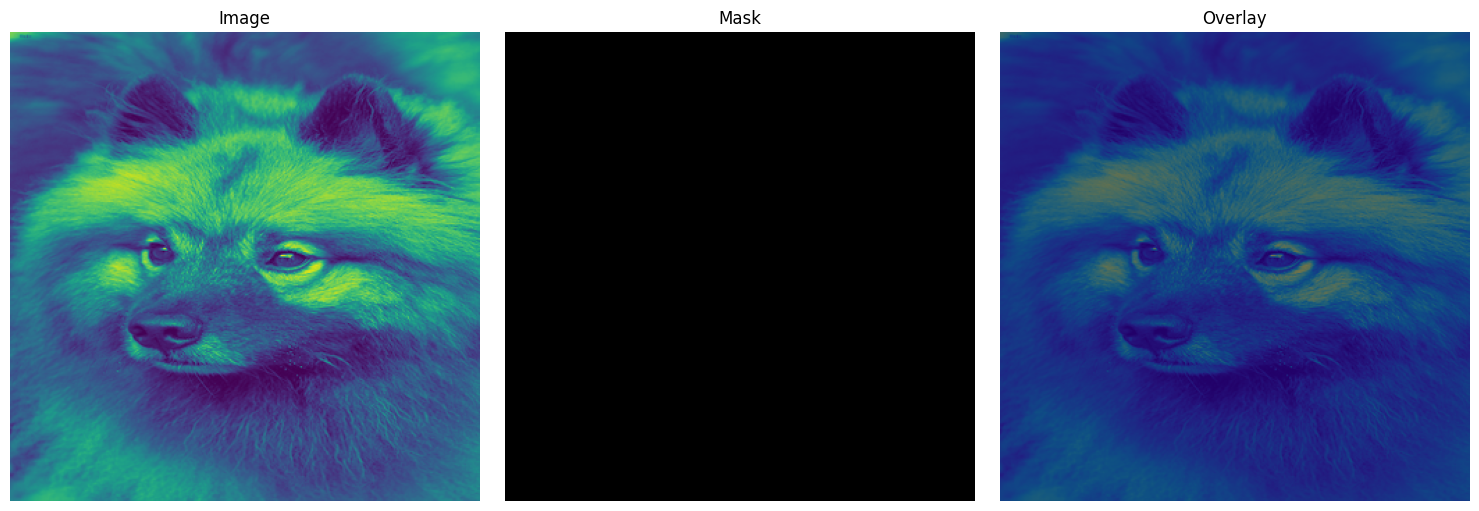

torch.Size([1, 338, 338])


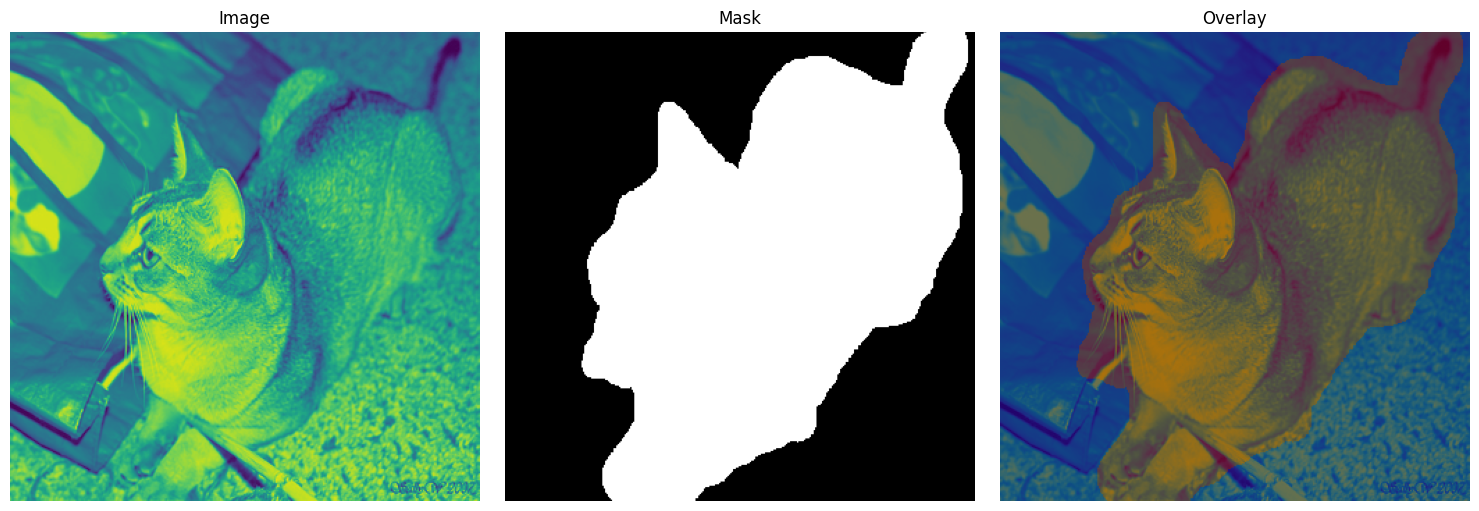

In [2]:
import os
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random

def get_filenames(txt_path):
    filenames = []
    with open(txt_path, "r", encoding="utf-8") as f:
        for line in f:
            name = line.strip()
            if name:
                filenames.append(name)

    return filenames

class OxfordPetDataset(Dataset):
    def __init__(self, image_dir, mask_dir, txt_path, img_size=388, mode="train", binary=True):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.mode = mode
        self.binary = binary

        # self.filenames = [f.split('.')[0] for f in os.listdir(image_dir)]
        self.filenames = get_filenames(txt_path)
        self.filenames.sort()
        # if mode == 'eval':
        #     self.img_size = None
        # if mode == 'test':
        #     print(self.filenames)

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        name = self.filenames[idx]

        img_path = os.path.join(self.image_dir, name + ".jpg")
        mask_path = os.path.join(self.mask_dir, name + ".png")
        # print(mask_path)

        image = Image.open(img_path).convert('L')
        mask = Image.open(mask_path)
        origin_shape = image.size
        # shape = image.size

        # ---------- Resize ----------
        if self.img_size is not None:
            image = image.resize((self.img_size, self.img_size))
            mask = mask.resize((self.img_size, self.img_size), resample=Image.NEAREST)

        # ---------- Data Augmentation ----------
        if self.mode == "train":
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

            # random rotation
            angle = random.uniform(-20, 20)
            image = TF.rotate(image, angle)
            mask = TF.rotate(mask, angle)

        # ---------- To Tensor ----------
        image = TF.to_tensor(image)  # [0,1]
        mask = torch.from_numpy(np.array(mask)).long()

        # ---------- Label 處理 ----------
        # 原始: 1=pet, 2=background, 3=boundary
        if self.binary:
            mask[mask == 2] = 0
            mask[mask == 1] = 1
            mask[mask == 3] = 1
        else:
            mask = mask - 1  # 變成 0,1,2
        if self.mode == 'test' or self.mode == 'eval':
            return image, mask, origin_shape,name
        else:
            return image, mask #if self.mode == 'train' or self.mode == 'val' else image, mask, shape, name
    

def get_dataloader(image_dir, mask_dir,txt_dir, model = 'unet', batch_size=8, img_size=256):
    if model == 'unet':
        test_txt_name = 'test_unet.txt'
    else:
        test_txt_name = 'test_res_unet.txt'

    train_dataset = OxfordPetDataset(
        image_dir=image_dir,
        mask_dir=mask_dir,
        txt_path=os.path.join(txt_dir,'train.txt'),
        img_size=img_size,
        mode="train",
        binary=True
    )
    val_dataset = OxfordPetDataset(
        image_dir=image_dir,
        mask_dir=mask_dir,
        txt_path=os.path.join(txt_dir,'val.txt'),
        img_size=img_size,
        mode="val",
        binary=True
    )
    test_dataset = OxfordPetDataset(
        image_dir=image_dir,
        mask_dir=mask_dir,
        txt_path=os.path.join(txt_dir,test_txt_name),
        img_size=img_size,
        mode="test",
        binary=True
    )
    print(f"Train samples: {len(train_dataset)}")
    print(f"Valid samples: {len(val_dataset)}")
    print(f"test samples: {len(test_dataset)}")

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader

# if __name__ == '__main__':
image_dir = '/home/andylin/workspace/deeplearning/dataset/images'
mask_dir = '/home/andylin/workspace/deeplearning/dataset/annotations/trimaps'
txt_dir = '/home/andylin/workspace/deeplearning/dataset/splits'
# train_loader, val_loader, test_loader = get_dataloader(image_dir,mask_dir,txt_dir)
# for image,masks in train_loader:
#     print(masks[0])
#     break
train_dataset = OxfordPetDataset(
        image_dir=image_dir,
        mask_dir=mask_dir,
        txt_path=os.path.join(txt_dir,'train.txt'),
        img_size=338,
        mode="test",
        binary=True
    )
min_sum = 250000
current_idx = None
for idx,item in enumerate(train_dataset):
    (image, mask, origin_shape,name) = item
    mask = mask.detach().cpu().numpy().astype(np.uint8)
    pixels = mask.flatten(order="F")
    if pixels.sum()<min_sum:
        min_sum = pixels.sum()
        current_idx = idx
print(current_idx)
visualize_sample(train_dataset,current_idx)


train_dataset = OxfordPetDataset(
        image_dir=image_dir,
        mask_dir=mask_dir,
        txt_path=os.path.join(txt_dir,'val.txt'),
        img_size=338,
        mode="test",
        binary=True
    )
min_sum = 250000
current_idx = None
for idx,item in enumerate(train_dataset):
    (image, mask, origin_shape,name) = item
    mask = mask.detach().cpu().numpy().astype(np.uint8)
    pixels = mask.flatten(order="F")
    if pixels.sum()<min_sum:
        min_sum = pixels.sum()
        current_idx = idx
print(current_idx)
visualize_sample(train_dataset,current_idx)
train_dataset = OxfordPetDataset(
        image_dir=image_dir,
        mask_dir=mask_dir,
        txt_path=os.path.join(txt_dir,'test_unet.txt'),
        img_size=338,
        mode="test",
        binary=True
    )
min_sum = 250000
current_idx = None
for idx,item in enumerate(train_dataset):
    (image, mask, origin_shape,name) = item
    mask = mask.detach().cpu().numpy().astype(np.uint8)
    pixels = mask.flatten(order="F")
    if pixels.sum()<min_sum:
        min_sum = pixels.sum()
        current_idx = idx
print(current_idx)
visualize_sample(train_dataset,current_idx)
print(train_dataset[0][0].size())
visualize_sample(train_dataset,0)

497


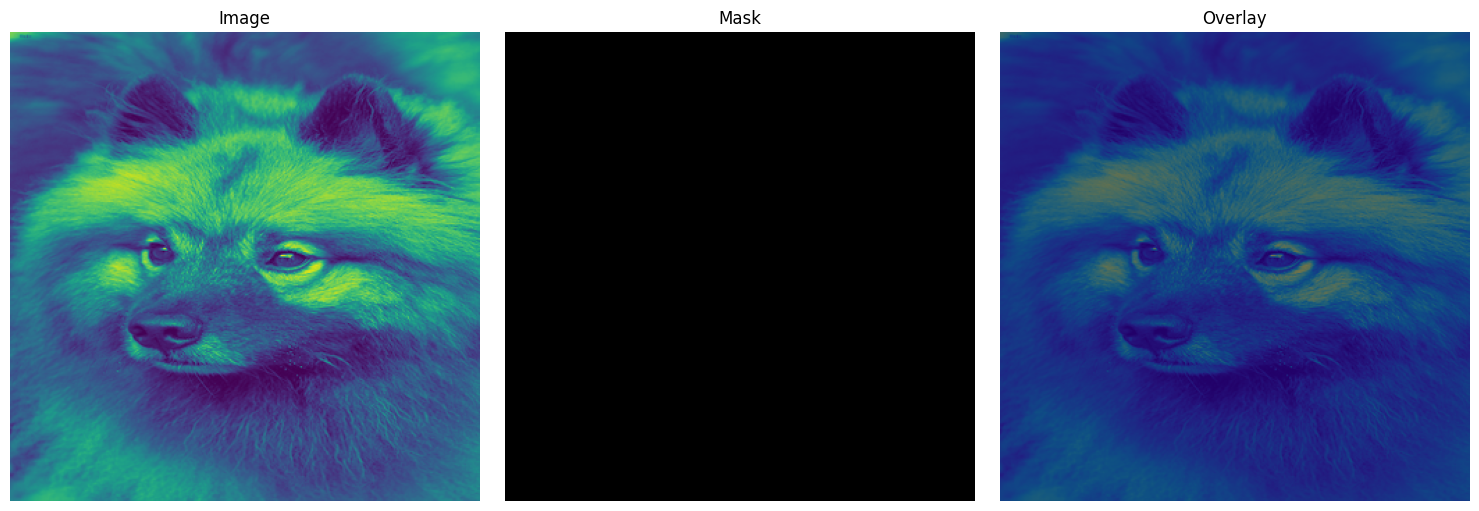

In [3]:
train_dataset = OxfordPetDataset(
        image_dir=image_dir,
        mask_dir=mask_dir,
        txt_path=os.path.join(txt_dir,'test_unet.txt'),
        img_size=338,
        mode="test",
        binary=True
    )
min_sum = 250000
current_idx = None
N = None
for idx,item in enumerate(train_dataset):
    (image, mask, origin_shape,name) = item
    mask = mask.detach().cpu().numpy().astype(np.uint8)
    pixels = mask.flatten(order="F")
    if pixels.sum()<min_sum:
        min_sum = pixels.sum()
        
        N = name
        current_idx = idx
print(current_idx)
visualize_sample(train_dataset,current_idx)

In [4]:
print(N)

keeshond_7
